In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
import librosa
import librosa.display

📥 Step 2: Load an Audio File

In [87]:
audio_path = "../sound effects/gun3.mp3"
# audio_path1 = "../sound effects/crash1.mp3"
# audio_path2 = "../sound effects/test.mp3"
y, sr = librosa.load(audio_path, sr=22050)
# y1, sr1 = librosa.load(audio_path1, sr=22050) # load audio with 22.05kHz sample rate
# y2, sr2 = librosa.load(audio_path2, sr=22050) # load audio with 22.05kHz sample rate


🎨 Step 3: Generate Mel Spectrogram and Plot

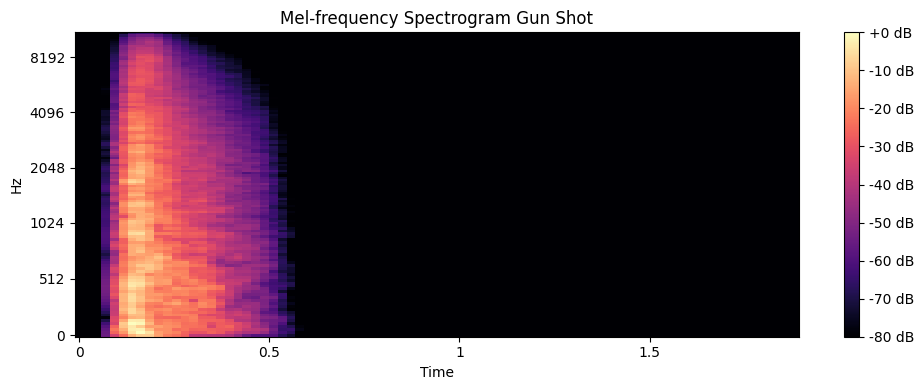

In [89]:
# Generate Mel Spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_DB = librosa.power_to_db(S, ref=np.max)

# Plot spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_DB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-frequency Spectrogram Gun Shot')
plt.tight_layout()
# Save the Mel Spectrogram as an image
plt.savefig('test2.png', dpi=300, bbox_inches='tight')
plt.show()

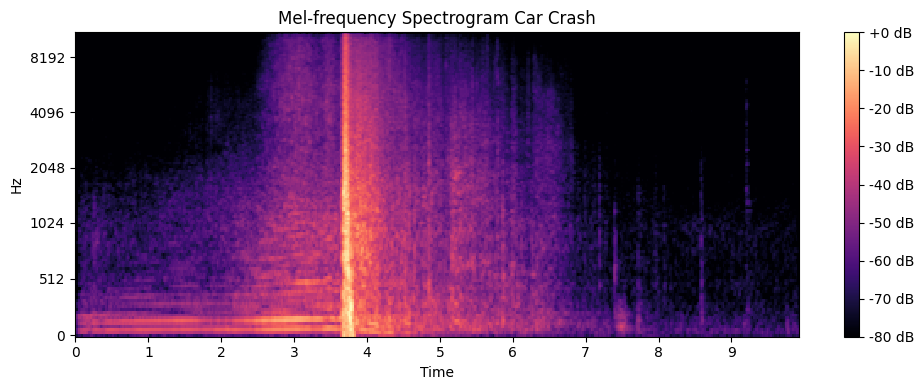

In [ ]:
# # Generate Mel Spectrogram
# S = librosa.feature.melspectrogram(y=y1, sr=sr1, n_mels=128)
# S_DB = librosa.power_to_db(S, ref=np.max)

# # Plot spectrogram
# plt.figure(figsize=(10, 4))
# librosa.display.specshow(S_DB, sr=sr1, x_axis='time', y_axis='mel')
# plt.colorbar(format='%+2.0f dB')
# plt.title('Mel-frequency Spectrogram Car Crash')
# plt.tight_layout()
# # Save the Mel Spectrogram as an image
# plt.savefig('spectrogram_crash1.png', dpi=300, bbox_inches='tight')
# plt.show()

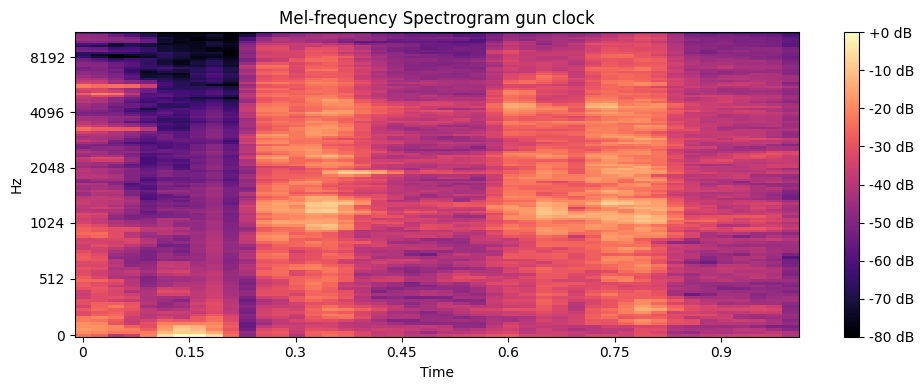

In [ ]:
# # Generate Mel Spectrogram
# S = librosa.feature.melspectrogram(y=y2, sr=sr2, n_mels=128)
# S_DB = librosa.power_to_db(S, ref=np.max)

# # Plot spectrogram
# plt.figure(figsize=(10, 4))
# librosa.display.specshow(S_DB, sr=sr2, x_axis='time', y_axis='mel')
# plt.colorbar(format='%+2.0f dB')
# plt.title('Mel-frequency Spectrogram gun clock')
# plt.tight_layout()
# # Save the Mel Spectrogram as an image
# plt.savefig('spectrogram_gunclock.png', dpi=300, bbox_inches='tight')
# plt.show()

In [21]:
input_folder = '../sound effects'
output_folder = '../spectogram dataset'

os.makedirs(output_folder, exist_ok=True)
# mp3 or wav files
for filename in os.listdir(input_folder):
    if filename.endswith('.mp3' or filename.endswith('.wav')):
        filepath = os.path.join(input_folder, filename)
        y, sr = librosa.load(filepath, sr=22050)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_DB = librosa.power_to_db(S, ref=np.max)

        plt.figure(figsize=(3, 3))
        librosa.display.specshow(S_DB, sr=sr, x_axis='time', y_axis='mel')
        plt.axis('off')
        output_path = os.path.join(output_folder, filename.replace('.mp3', '.png'))
        plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
        plt.close()

#### Model Buildinng Phase CNN 🔥

In [22]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import os

In [79]:
dataset_path = '../spectrogram dataset/'

# Define image size (your current size: 232 x 231)
img_height, img_width = 232, 231
batch_size = 16

# Data generator (with normalization and validation split)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.0
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 9 images belonging to 4 classes.
Found 0 images belonging to 4 classes.


In [54]:
num_classes = train_generator.num_classes

# Build CNN model from scratch
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])


In [55]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [56]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 230, 229, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 115, 114, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 113, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 54, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     5,972,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,065,540 (23.14 MB)

 Trainable params: 6,065,540 (23.14 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# Train the model
history = model.fit(
    train_generator,
    # validation_data=val_generator,
    epochs=15
)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2222 - loss: 1.3902
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step - accuracy: 0.4444 - loss: 2.9928
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.3333 - loss: 1.2878
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.3333 - loss: 1.3194
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.5556 - loss: 1.0761
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.7778 - loss: 0.8202
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.7778 - loss: 0.7532
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.6667 - loss: 0.6438
Epoch 9/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 1.0000 - loss: 0.3829
Epoch 10/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.8889 - loss: 0.3319
Epoch 11/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 1.0000 - loss: 0.1235
Epoch 12/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 1.0000 - loss:

# Save the trained model

In [58]:
model.save('sound_effects_cnn_model.keras')


🧪 3. Evaluate After Training

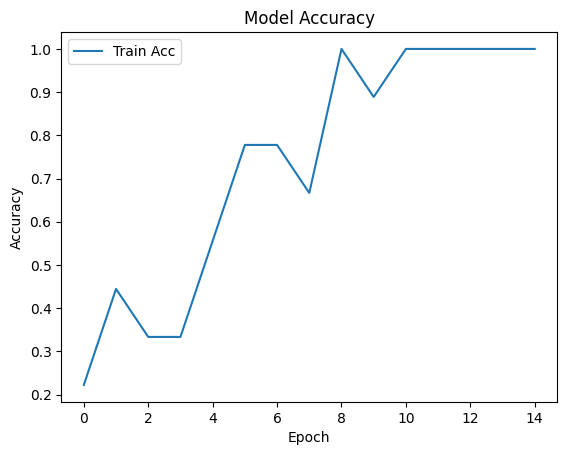

In [59]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
# plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()


In [90]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img('../spectrogram dataset/test2.png', target_size=(img_height, img_width))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)
class_indices = train_generator.class_indices
labels = list(class_indices.keys())

predicted_class = labels[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step
Predicted: gun
